# **EXP 1 : Explore the descriptive statistics on the given dataset.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, poisson
import statsmodels.api as sm
from statsmodels.stats import weightstats

df = pd.read_csv('loan_data_set.csv')

!pip install tabulate

print(df.shape)
df.head()

print(df.describe())

def statistics(data):
    stats_dict = {}

    stats_dict['Range'] = data.max() - data.min()

    # Quartile measures
    stats_dict['First Quartile'] = data.quantile(0.25)
    stats_dict['Third Quartile'] = data.quantile(0.75)
    stats_dict['IQR'] = stats_dict['Third Quartile'] - stats_dict['First Quartile']

    # Dispersion measures
    stats_dict['Standard Deviation'] = data.std()
    stats_dict['Variance'] = data.var()
    stats_dict['SE of Mean'] = stats_dict['Standard Deviation'] / np.sqrt(len(data))
    stats_dict['Coefficient of Variation'] = (stats_dict['Standard Deviation'] / data.mean()) * 100

    # Count measures
    stats_dict['N Total'] = len(data)
    stats_dict['N Missing'] = data.isna().sum()

    # Distribution measures
    stats_dict['Skewness'] = data.skew()
    stats_dict['Kurtosis'] = data.kurtosis()
    stats_dict['Sum'] = data.sum()
    stats_dict['Sum of Squares'] = (data ** 2).sum()

    # Trimmed statistics
    stats_dict['Trimmed Mean (10%)'] = stats.trim_mean(data, 0.1)

    return pd.Series(stats_dict)

numerical_columns = df.select_dtypes(include=[np.number]).columns
desc_stats = pd.DataFrame({col: statistics(df[col]) for col in numerical_columns})
print(desc_stats.astype('int64'))

def distribution_analysis(data, column):
    # Normal distribution test
    statistic, p_value = stats.normaltest(data[column])
    print(f"\nNormal Distribution Test for {column}:")
    print(f"Statistic: {statistic:.4f}")
    print(f"P-value: {p_value:.4f}")

    # Poisson distribution test
    lambda_param = data[column].mean()
    poisson_dist = poisson(lambda_param)
    ks_statistic, ks_p_value = stats.kstest(data[column], poisson_dist.cdf)
    print(f"\nPoisson Distribution Test for {column}:")
    print(f"KS Statistic: {ks_statistic:.4f}")
    print(f"P-value: {ks_p_value:.4f}")

    # Confidence Intervals
    ci = stats.t.interval(0.95, len(data[column])-1, loc=np.mean(data[column]), scale=stats.sem(data[column]))
    print(f"\n95% Confidence Interval: ({ci[0]:.4f}, {ci[1]:.4f})")


# Perform distribution analysis on numerical columns
for column in numerical_columns:
    print(f"\nAnalysis for {column}")
    distribution_analysis(df, column)

def hypothesis_testing(data, column1, column2=None):
    # One-sample z-test
    ztest_statistic, ztest_p_value = weightstats.ztest(data[column1])
    print(f"\nOne-sample Z-test for {column1}:")
    print(f"Z-statistic: {ztest_statistic:.4f}")
    print(f"P-value: {ztest_p_value:.4f}")

    if column2:
        # Two-sample t-test
        ttest_statistic, ttest_p_value = stats.ttest_ind(data[column1], data[column2])
        print(f"\nTwo-sample t-test between {column1} and {column2}:")
        print(f"T-statistic: {ttest_statistic:.4f}")
        print(f"P-value: {ttest_p_value:.4f}")

        # One-way ANOVA
        groups = [data[column1], data[column2]]
        f_statistic, anova_p_value = stats.f_oneway(*groups)
        print(f"\nOne-way ANOVA:")
        print(f"F-statistic: {f_statistic:.4f}")
        print(f"P-value: {anova_p_value:.4f}")

# Perform hypothesis testing
if len(numerical_columns) >= 2:
    hypothesis_testing(df, numerical_columns[0], numerical_columns[1])
else:
    hypothesis_testing(df, numerical_columns[0])

# Calculate Type I and Type II error probabilities
alpha = 0.05  # Type I error rate
beta = 0.2    # Type II error rate (assumed)
print("\nType I and Type II Errors:")
print(f"Type I Error (α) probability: {alpha}")
print(f"Type II Error (β) probability: {beta}")
print(f"Power (1-β): {1-beta}")

(614, 13)
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  592.000000         600.00000   
mean       5403.459283        1621.245798  146.412162         342.00000   
std        6109.041673        2926.248369   85.587325          65.12041   
min         150.000000           0.000000    9.000000          12.00000   
25%        2877.500000           0.000000  100.000000         360.00000   
50%        3812.500000        1188.500000  128.000000         360.00000   
75%        5795.000000        2297.250000  168.000000         360.00000   
max       81000.000000       41667.000000  700.000000         480.00000   

       Credit_History  
count      564.000000  
mean         0.842199  
std          0.364878  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  
                          ApplicantIncome  CoapplicantIncome  LoanAmount  \
Range                 

# **EXP 2 : Apply data cleaning techniques (e.g. Data Imputation).**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as snsa
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

# Load the dataset
df = pd.read_csv('loan_data_set.csv')
df_original = df.copy()  # Keep original for comparison

# Display initial missing values
print("Initial missing values:")
print(df.isnull().sum())
# print(df.shape)

# Analyze relationships for LoanAmount
numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
correlation = df[numeric_cols].corr()
print("\nCorrelation with LoanAmount:")
print(correlation['LoanAmount'])

# 1. Optimal Imputation Strategy by Column Type:

# For LoanAmount: Regression Imputation (due to correlation with income)
X = df[['ApplicantIncome', 'CoapplicantIncome']].copy()
y = df['LoanAmount'].copy()
mask = ~y.isnull()
reg_model = LinearRegression()
reg_model.fit(X[mask], y[mask])
missing_mask = y.isnull()
df.loc[missing_mask, 'LoanAmount'] = reg_model.predict(X[missing_mask])

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# For Loan_Amount_Term: Median Imputation (since it's a standardized value)
term_median = df['Loan_Amount_Term'].median()
df['Loan_Amount_Term'].fillna(term_median, inplace=True)

# For Categorical Variables: Mode Imputation
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nRemaining missing values after imputation:")
print(df.isnull().sum())

# Statistical comparison before and after imputation
def compare_stats(original, imputed, column):
    stats_orig = original[column].describe()
    stats_imp = imputed[column].describe()
    comparison = pd.concat([stats_orig, stats_imp], axis=1)
    comparison.columns = ['Original', 'Imputed']
    return comparison

print("\nLoanAmount Statistics Comparison:")
print(compare_stats(df_original, df, 'LoanAmount'))

# Categorical variables distribution comparison
for col in categorical_cols:
    if df_original[col].isnull().sum() > 0:
        print(f"\n{col} Distribution Comparison:")
        print("Original:")
        print(df_original[col].value_counts(normalize=True))
        print("\nImputed:")
        print(df[col].value_counts(normalize=True))


# Save the imputed dataset
df.to_csv('loan_dataset_imputed.csv', index=False)
print("\nImputed dataset saved as 'loan_dataset_imputed.csv'")

Initial missing values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Correlation with LoanAmount:
ApplicantIncome      0.570909
CoapplicantIncome    0.188619
LoanAmount           1.000000
Loan_Amount_Term     0.039447
Name: LoanAmount, dtype: float64

Remaining missing values after imputation:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

LoanAmount Statistics Comparison:
         Original     Imputed
count  592.000000  614.000000
mean   146.412162

# **EXP 3 : Explore data visualization techniques.**

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


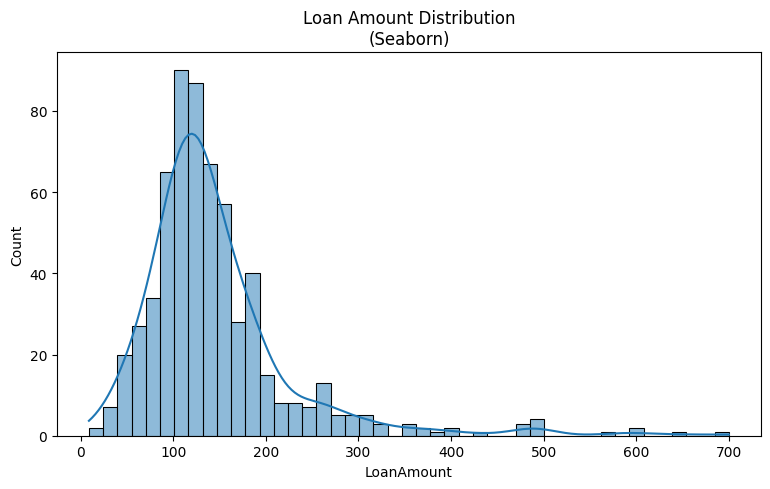

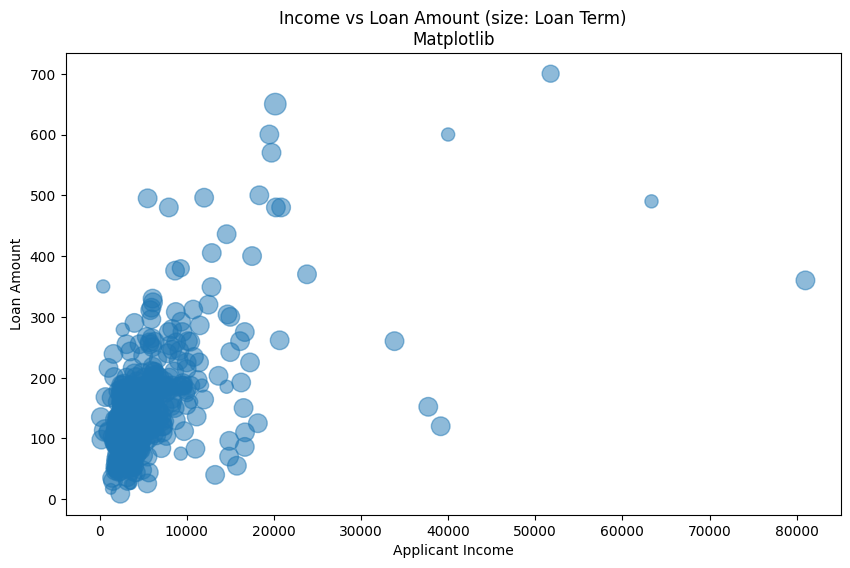

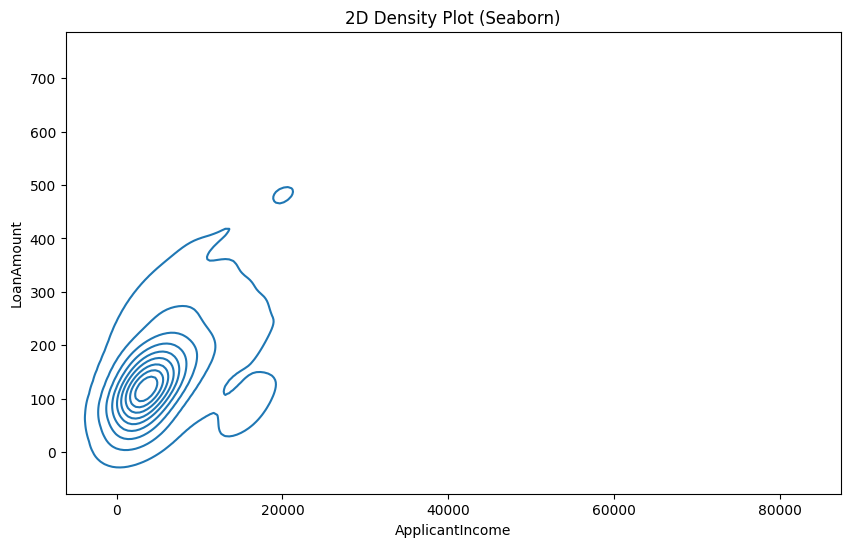

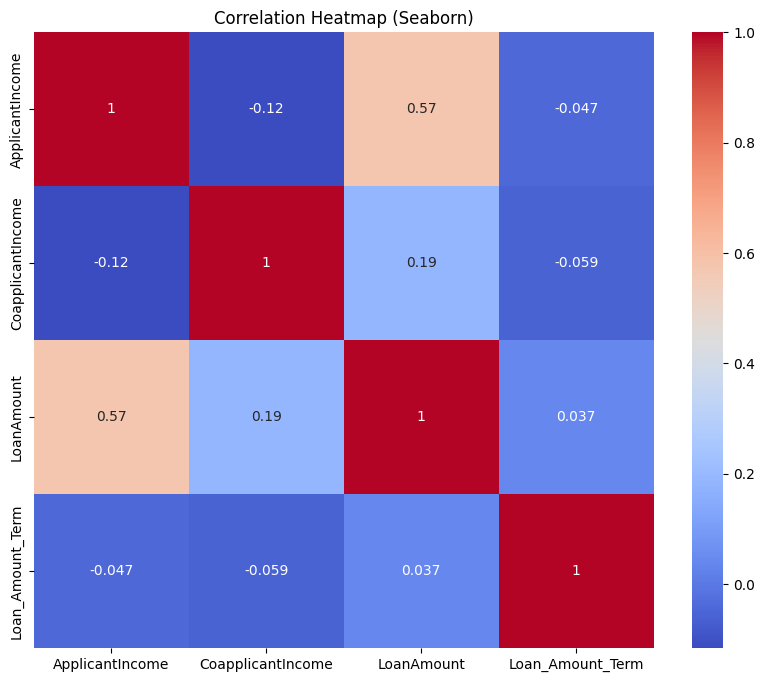

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('loan_dataset_imputed.csv')

print(df.isnull().sum())

# Seaborn histogram
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='LoanAmount', kde=True) #kernel density estimate (KDE) overlay to smooth the distribution.
plt.title('Loan Amount Distribution\n(Seaborn)')

# Plotly histogram
fig = px.histogram(df, x='LoanAmount', title='Loan Amount Distribution (Plotly)')
fig.show()

plt.tight_layout()
plt.show()

# Plotly scatter matrix
numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
fig = px.scatter_matrix(df[numeric_cols],title='Scatter Matrix (Plotly)')
fig.show()

# Matplotlib bubble chart
plt.figure(figsize=(10, 6))
plt.scatter(df['ApplicantIncome'], df['LoanAmount'], s=df['Loan_Amount_Term']/2, alpha=0.5)
plt.title('Income vs Loan Amount (size: Loan Term)\nMatplotlib')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.show()

# Plotly bubble chart
fig = px.scatter(df, x='ApplicantIncome', y='LoanAmount',size='Loan_Amount_Term', color='Education',title='Income vs Loan Amount with Loan Term (Plotly)')
fig.show()

# Seaborn 2D density
plt.figure(figsize=(10, 6))

sns.kdeplot(data=df, x='ApplicantIncome', y='LoanAmount')
plt.title('2D Density Plot (Seaborn)')
plt.show()

# Plotly 2D density
fig = px.density_heatmap(df, x='ApplicantIncome', y='LoanAmount',
                        title='2D Density Plot (Plotly)')
fig.show()

# Seaborn correlation heatmap
plt.figure(figsize=(10, 8))
numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Seaborn)')
plt.show()

# Plotly correlation heatmap
fig = px.imshow(df[numeric_cols].corr(),
                title='Correlation Heatmap (Plotly)')
fig.show()



# **EXP 4 :  Implement and explore performance evaluation metrics for Data Models (Supervised)**

Accuracy: 0.6911
Error Rate: 0.3089
Precision: 0.7561
Sensitivity/Recall: 0.7750
Specificity: 0.5349
ROC AUC: 0.6549
F1 Score: 0.7654
Geometric Mean: 0.6438
False Positive Rate: 0.4651
False Negative Rate: 0.2250
Power: 0.7750


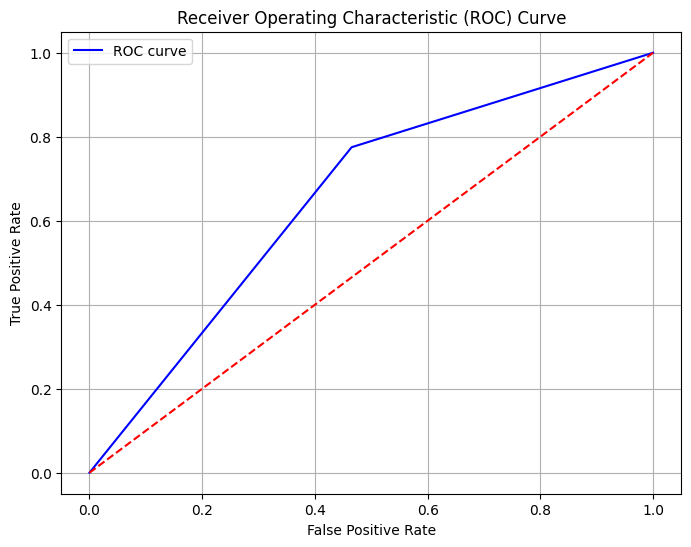

Pearson Correlation: 0.7567
R-squared: 0.5595
RMSE: 0.5885
MAE: 0.4298
MAPE: 116.1725


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('loan_dataset_imputed.csv')

df.head()

df.describe()

df.isnull().sum()

df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce')

le = LabelEncoder()
categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Show the first few rows to check transformations
df.head()

scaler = StandardScaler()
numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Show the first few rows to check transformations
df.describe().astype('int64')

# Prepare features and target for classification
X = df.drop(['Loan_Status', 'Loan_ID'], axis=1)
y = df['Loan_Status']

# Split the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Show the shape of the resulting datasets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

from sklearn.tree import DecisionTreeClassifier

# Train a Decision Tree model for classification
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate confusion matrix elements
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Calculate basic metrics
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
precision = precision_score(y_test, y_pred)
sensitivity = recall_score(y_test, y_pred)
specificity = tn / (tn + fp)

# Calculate advanced metrics
fpr = fp / (fp + tn)  # False positive rate
fnr = fn / (fn + tp)  # False negative rate
power = sensitivity  # Power = sensitivity

# Calculate geometric mean
g_mean = np.sqrt(sensitivity * specificity)

# Calculate F1 score
f1 = 2 * (precision * sensitivity) / (precision + sensitivity)

# ROC AUC score
roc_auc = roc_auc_score(y_test, y_prob)

# Display the metrics
metrics = {
    'Accuracy': accuracy,
    'Error Rate': error_rate,
    'Precision': precision,
    'Sensitivity/Recall': sensitivity,
    'Specificity': specificity,
    'ROC AUC': roc_auc,
    'F1 Score': f1,
    'Geometric Mean': g_mean,
    'False Positive Rate': fpr,
    'False Negative Rate': fnr,
    'Power': power
}

# Print classification metrics
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

    fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

# For regression metrics example (using LoanAmount as target)
y_reg = df['LoanAmount']
X_reg = df.drop(['LoanAmount', 'Loan_Status', 'Loan_ID'], axis=1)

# Split the data into training and test sets for regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Show the shape of the resulting datasets
X_train_reg.shape, X_test_reg.shape, y_train_reg.shape, y_test_reg.shape

# Train a Linear Regression model for regression
reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)


# Make predictions on the test set (regression)
y_pred_reg = reg_model.predict(X_test_reg)

# Pearson Correlation
pearson_corr = np.corrcoef(y_test_reg, y_pred_reg)[0, 1]

# R-squared
r2 = r2_score(y_test_reg, y_pred_reg)

# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))

# MAE (Mean Absolute Error)
mae = mean_absolute_error(y_test_reg, y_pred_reg)

# MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((y_test_reg - y_pred_reg) / y_test_reg)) * 100

# Display the metrics
reg_metrics = {
    'Pearson Correlation': pearson_corr,
    'R-squared': r2,
    'RMSE': rmse,
    'MAE': mae,
    'MAPE': mape
}

# Print regression metrics
for metric, value in reg_metrics.items():
    print(f"{metric}: {value:.4f}")


# **EXP 5 : Implement and explore performance evaluation metrics for Data Models (Unsupervised Learning)**

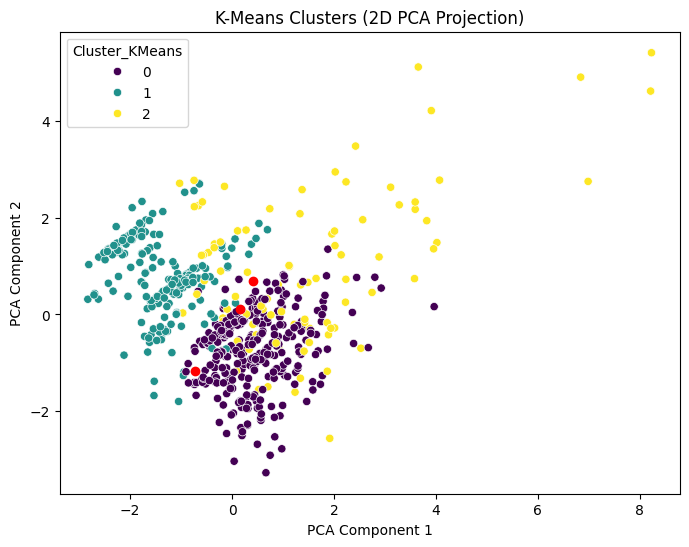

K-Means Silhouette Score: 0.15461506243395562
K-Means Adjusted Rand Index: 0.012955564272634279
K-Means Mutual Information: 0.003703527583332383


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA

# Load dataset
file_path = "loan_dataset_imputed.csv"
df = pd.read_csv(file_path)

# Drop Loan_ID but keep Loan_Status for evaluation
ground_truth = df["Loan_Status"]
df_unsupervised = df.drop(columns=["Loan_ID", "Loan_Status"])

# Encode categorical features
categorical_cols = df_unsupervised.select_dtypes(include=["object"]).columns
label_encoders = {col: LabelEncoder() for col in categorical_cols}
for col in categorical_cols:
    df_unsupervised[col] = label_encoders[col].fit_transform(df_unsupervised[col])

# Normalize numerical features
scaler = StandardScaler()
df_unsupervised[df_unsupervised.columns] = scaler.fit_transform(df_unsupervised)

# Encode ground truth labels
ground_truth_encoded = LabelEncoder().fit_transform(ground_truth)

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_unsupervised["Cluster_KMeans"] = kmeans.fit_predict(df_unsupervised)

# K-Means evaluation
silhouette_kmeans = silhouette_score(df_unsupervised.drop(columns=["Cluster_KMeans"]), df_unsupervised["Cluster_KMeans"])
rand_index_kmeans = adjusted_rand_score(ground_truth_encoded, df_unsupervised["Cluster_KMeans"])
mutual_info_kmeans = normalized_mutual_info_score(ground_truth_encoded, df_unsupervised["Cluster_KMeans"])

# Apply DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
df_unsupervised["Cluster_DBSCAN"] = dbscan.fit_predict(df_unsupervised.drop(columns=["Cluster_KMeans"]))

# DBSCAN evaluation (Silhouette Score only if more than 1 cluster is detected)
if len(set(dbscan.labels_)) > 1:
    silhouette_dbscan = silhouette_score(df_unsupervised.drop(columns=["Cluster_KMeans", "Cluster_DBSCAN"]), df_unsupervised["Cluster_DBSCAN"])
    rand_index_dbscan = adjusted_rand_score(ground_truth_encoded, df_unsupervised["Cluster_DBSCAN"])
    mutual_info_dbscan = normalized_mutual_info_score(ground_truth_encoded, df_unsupervised["Cluster_DBSCAN"])
else:
    silhouette_dbscan = "N/A"
    rand_index_dbscan = "N/A"
    mutual_info_dbscan = "N/A"

# PCA for Cluster Visualization
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_unsupervised.drop(columns=["Cluster_KMeans", "Cluster_DBSCAN"]))

plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_pca[:, 0], y=df_pca[:, 1], hue=df_unsupervised["Cluster_KMeans"], palette="viridis", legend="full")
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', label='Centroids')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clusters (2D PCA Projection)")
plt.show()

# Print results
print(f"K-Means Silhouette Score: {silhouette_kmeans}")
print(f"K-Means Adjusted Rand Index: {rand_index_kmeans}")
print(f"K-Means Mutual Information: {mutual_info_kmeans}")


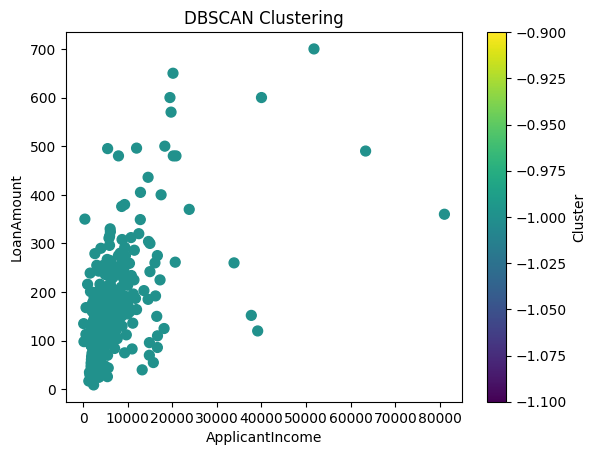

DBSCAN Silhouette Score: 0.13619014263434057
DBSCAN Adjusted Rand Index: 0.042242041322559876
DBSCAN Mutual Information: 0.08230278466431416


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA

# Load dataset
file_path = "loan_dataset_imputed.csv"
df = pd.read_csv(file_path)
# Apply DBSCAN clustering (density-based)
db = DBSCAN(eps=0.4, min_samples=10)
labels = db.fit_predict(df[['ApplicantIncome', 'LoanAmount']])

# Plot clusters and highlight outliers (label = -1)
plt.scatter(df['ApplicantIncome'], df['LoanAmount'], c=labels, cmap='viridis', s=50)
plt.title("DBSCAN Clustering")
plt.xlabel("ApplicantIncome")
plt.ylabel("LoanAmount")
plt.colorbar(label='Cluster')
plt.show()

print(f"DBSCAN Silhouette Score: {silhouette_dbscan}")
print(f"DBSCAN Adjusted Rand Index: {rand_index_dbscan}")
print(f"DBSCAN Mutual Information: {mutual_info_dbscan}")

## **EXP 6 : Implement time series forecasting.**

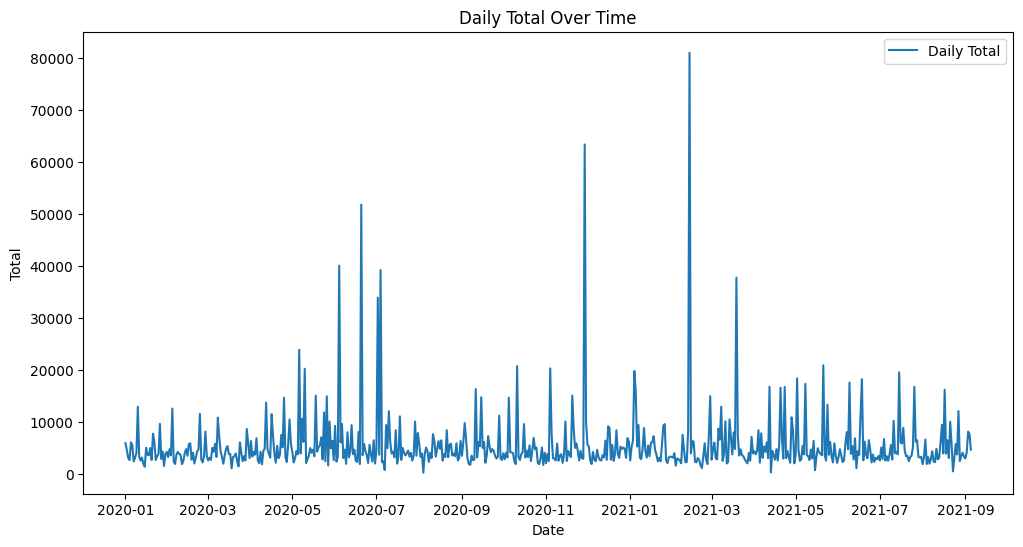

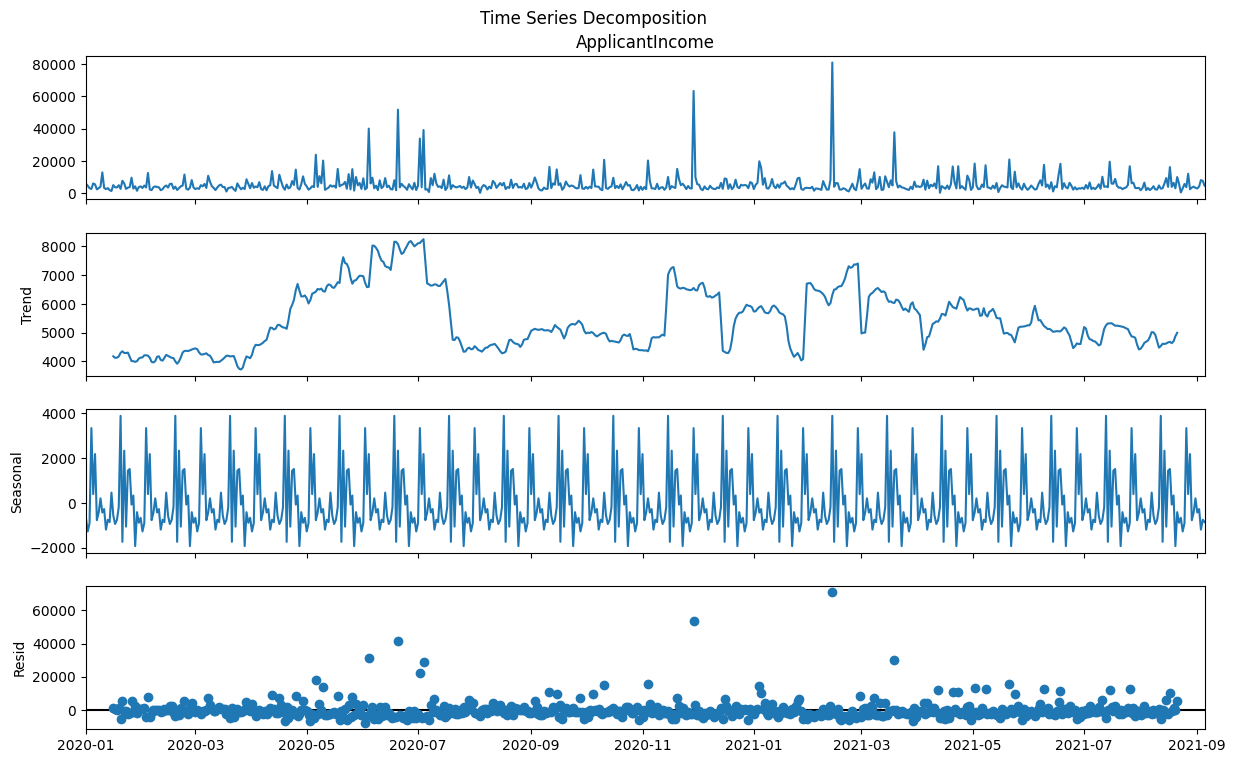

ADF Statistic: -25.0404
p-value: 0.0000
Data is stationary.
Linear Regression - MAE: 3168.37, RMSE: 4063.75
Moving Average - MAE: 2998.02, RMSE: 3979.81
ARIMA - MAE: 2754.48, RMSE: 3892.12


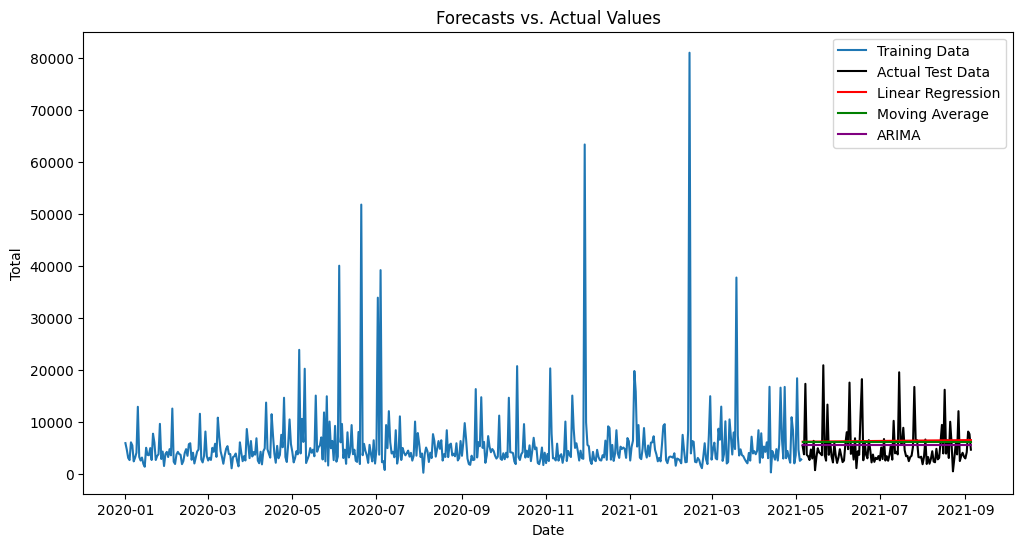

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime, timedelta
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("loan_dataset_imputed.csv")

# Ensure dataset has at least one numeric column
numeric_cols = df.select_dtypes(include=[np.number]).columns
if numeric_cols.empty:
    raise ValueError("Dataset does not contain numeric columns for aggregation.")

# Generate random dates within a specific range
df['Date'] = pd.date_range(start='2020-01-01', periods=len(df), freq='D')

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Aggregate Total by Date (using the first numeric column as default)
ts_data = df.groupby('Date')[numeric_cols[0]].sum()

# Ensure daily frequency
ts_data = ts_data.asfreq('D')

# Plot time series
plt.figure(figsize=(12, 6))
plt.plot(ts_data, label='Daily Total')
plt.title('Daily Total Over Time')
plt.xlabel('Date')
plt.ylabel('Total')
plt.legend()
plt.show()

# Time Series Decomposition
decomposition = seasonal_decompose(ts_data.dropna(), model='additive', period=30)
decomposition.plot().set_size_inches(14, 8)
plt.suptitle('Time Series Decomposition')
plt.show()

# ADF Test for Stationarity
adf_result = adfuller(ts_data.dropna())
print(f'ADF Statistic: {adf_result[0]:.4f}')
print(f'p-value: {adf_result[1]:.4f}')
if adf_result[1] < 0.05:
    print("Data is stationary.")
else:
    print("Data is not stationary.")

# Splitting data
split_idx = int(len(ts_data) * 0.8)
train, test = ts_data.iloc[:split_idx], ts_data.iloc[split_idx:]

# Linear Regression Model
train_df = train.reset_index()
train_df['time_idx'] = np.arange(len(train_df))
test_df = test.reset_index()
test_df['time_idx'] = np.arange(len(train_df), len(train_df) + len(test_df))

lr_model = LinearRegression()
lr_model.fit(train_df[['time_idx']], train_df[numeric_cols[0]])
lr_pred = lr_model.predict(test_df[['time_idx']])

# Moving Average Forecasting
moving_avg_value = train.rolling(window=7).mean().iloc[-1]
ma_pred = pd.Series(moving_avg_value, index=test.index)

# ARIMA Forecasting
arima_model = ARIMA(train, order=(1, 1, 1))
arima_result = arima_model.fit()
arima_pred = arima_result.forecast(steps=len(test))

# Evaluation Function
def evaluate_forecast(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    print(f"{model_name} - MAE: {mae:.2f}, RMSE: {rmse:.2f}")
    return mae, rmse

# Evaluate Models
evaluate_forecast(test, lr_pred, "Linear Regression")
evaluate_forecast(test, ma_pred, "Moving Average")
evaluate_forecast(test, arima_pred, "ARIMA")

# Plot Forecasts
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Test Data', color='black')
plt.plot(test.index, lr_pred, label='Linear Regression', color='red')
plt.plot(test.index, ma_pred, label='Moving Average', color='green')
plt.plot(test.index, arima_pred, label='ARIMA', color='purple')
plt.title('Forecasts vs. Actual Values')
plt.xlabel('Date')
plt.ylabel('Total')
plt.legend()
plt.show()


## **EXP 7 : Outlier detection using distance based/density based method.**

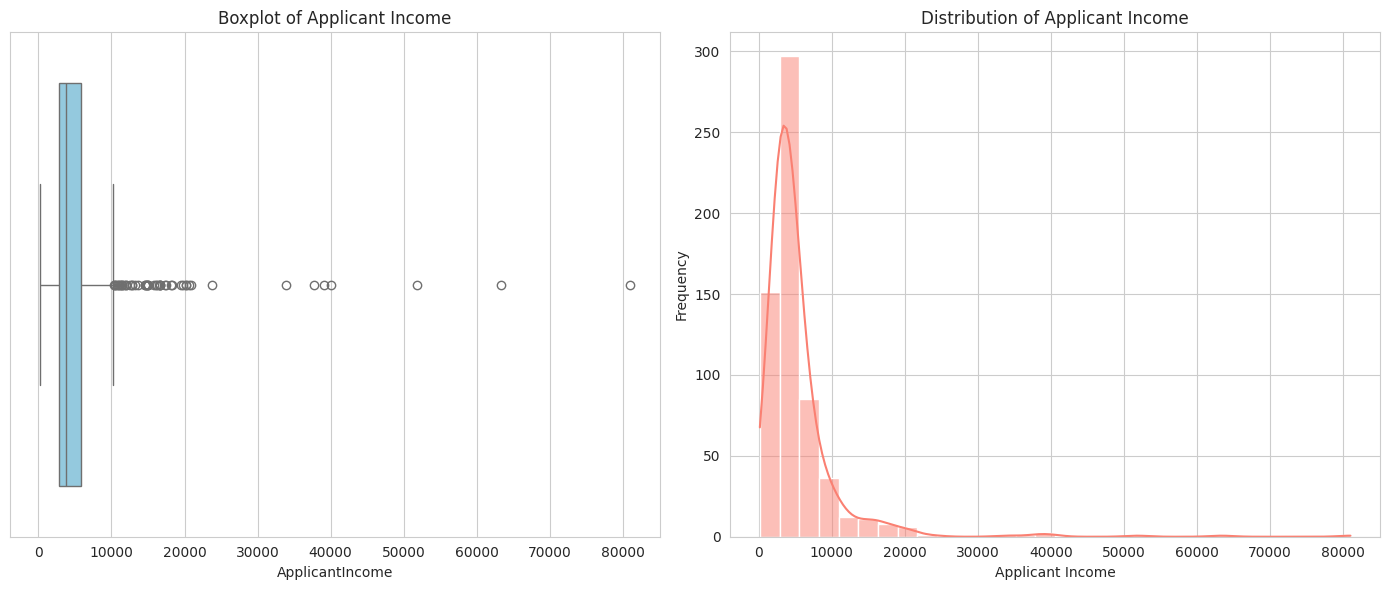

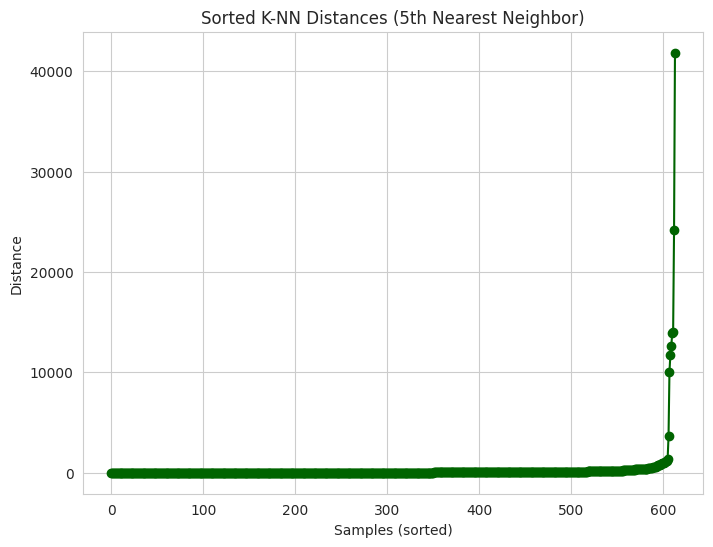

Number of outliers detected by K-NN: 30
Number of outliers detected by Local Outlier Factor (LOF): 31


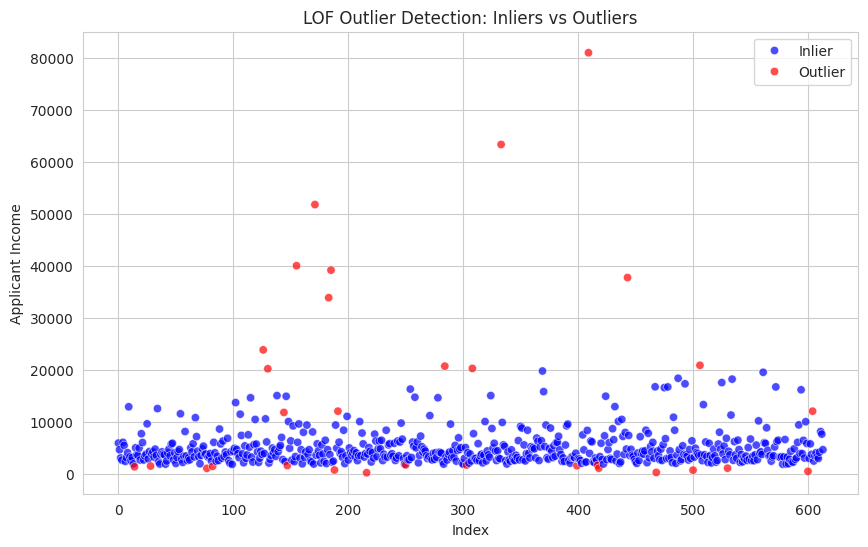

Lower bound (5th percentile): 1897.55
Upper bound (95th percentile): 14583.00


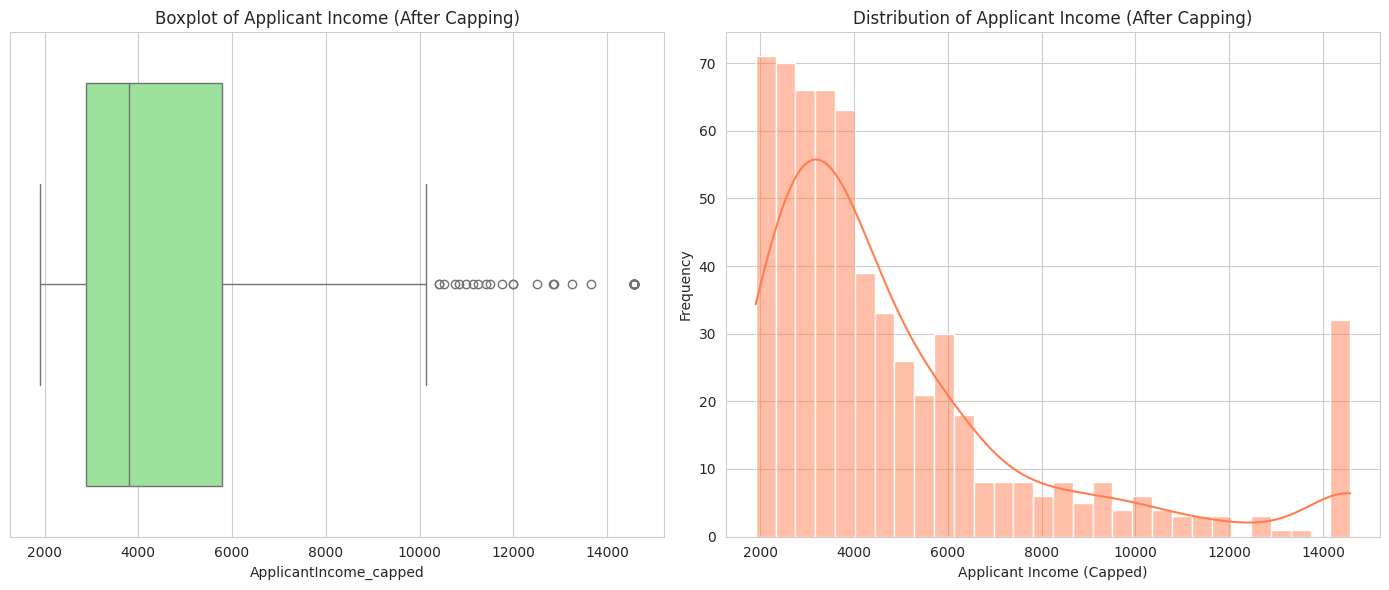

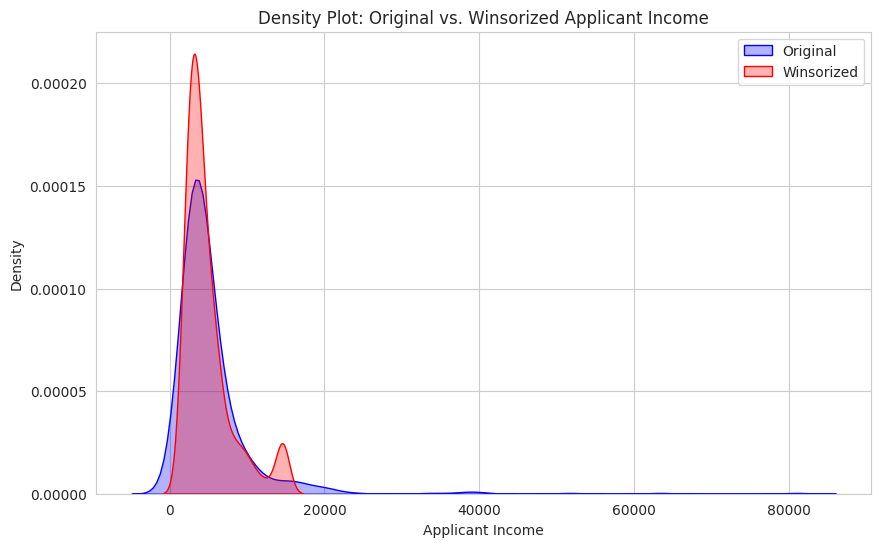

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.cluster import DBSCAN

warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("loan_dataset_imputed.csv")

# Ensure dataset has numeric column 'ApplicantIncome'
if 'ApplicantIncome' not in df.columns:
    raise ValueError("Dataset must contain 'ApplicantIncome' column.")


# 1. Visual Analysis of 'ApplicantIncome'

plt.figure(figsize=(14, 6))

# a) Boxplot to visualize extreme values
plt.subplot(1, 2, 1)
sns.boxplot(x=df['ApplicantIncome'], color='skyblue')
plt.title('Boxplot of Applicant Income')

# b) Distribution plot (Histogram with KDE)
plt.subplot(1, 2, 2)
sns.histplot(df['ApplicantIncome'], kde=True, color='salmon', bins=30)
plt.title('Distribution of Applicant Income')
plt.xlabel('Applicant Income')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 2. Distance Based Outlier Detection using K-NN

k = 5
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(df[['ApplicantIncome']])
distances, indices = neighbors_fit.kneighbors(df[['ApplicantIncome']])
df['knn_distance'] = distances[:, -1]

# Plot sorted k-NN distances
sorted_distances = np.sort(df['knn_distance'].values)
plt.figure(figsize=(8, 6))
plt.plot(sorted_distances, marker='o', linestyle='-', color='darkgreen')
plt.title('Sorted K-NN Distances (5th Nearest Neighbor)')
plt.xlabel('Samples (sorted)')
plt.ylabel('Distance')
plt.show()

# Define threshold for outlier detection
threshold = np.percentile(df['knn_distance'], 95)
df['knn_outlier'] = (df['knn_distance'] > threshold).astype(int)
print("Number of outliers detected by K-NN:", df['knn_outlier'].sum())

# 3. Density Based Outlier Detection using Local Outlier Factor (LOF)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df['lof_pred'] = lof.fit_predict(df[['ApplicantIncome']])
num_lof_outliers = (df['lof_pred'] == -1).sum()
print("Number of outliers detected by Local Outlier Factor (LOF):", num_lof_outliers)

# Visualize LOF results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df.index, y='ApplicantIncome',
                hue=df['lof_pred'].apply(lambda x: 'Outlier' if x == -1 else 'Inlier'),
                palette={'Inlier': 'blue', 'Outlier': 'red'},
                data=df, alpha=0.7)
plt.title("LOF Outlier Detection: Inliers vs Outliers")
plt.xlabel("Index")
plt.ylabel("Applicant Income")
plt.legend()
plt.show()


# 4. Outlier Handling: Capping (Winsorization)

lower_bound = df['ApplicantIncome'].quantile(0.05)
upper_bound = df['ApplicantIncome'].quantile(0.95)
print(f"Lower bound (5th percentile): {lower_bound:.2f}")
print(f"Upper bound (95th percentile): {upper_bound:.2f}")

df['ApplicantIncome_capped'] = df['ApplicantIncome'].clip(lower=lower_bound, upper=upper_bound)

df['ApplicantIncome_winsorized'] = stats.mstats.winsorize(df['ApplicantIncome'], limits=[0.05, 0.05])


# 5. Compare Distribution and Boxplot After Capping

plt.figure(figsize=(14, 6))

# Boxplot after capping
plt.subplot(1, 2, 1)
sns.boxplot(x=df['ApplicantIncome_capped'], color='lightgreen')
plt.title('Boxplot of Applicant Income (After Capping)')

# Histogram after capping
plt.subplot(1, 2, 2)
sns.histplot(df['ApplicantIncome_capped'], kde=True, color='coral', bins=30)
plt.title('Distribution of Applicant Income (After Capping)')
plt.xlabel('Applicant Income (Capped)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


# 6. Compare Original vs Winsorized Distributions

plt.figure(figsize=(10, 6))
sns.kdeplot(df['ApplicantIncome'], label='Original', color='blue', fill=True, alpha=0.3)
sns.kdeplot(df['ApplicantIncome_winsorized'], label='Winsorized', color='red', fill=True, alpha=0.3)
plt.title('Density Plot: Original vs. Winsorized Applicant Income')
plt.xlabel('Applicant Income')
plt.ylabel('Density')
plt.legend()
plt.show()


# **EXP 8 :  Use SMOTE technique to generate synthetic data.(to solve the problem of class imbalance)**

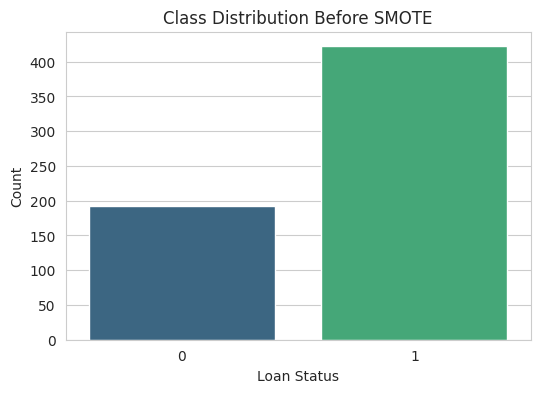

Class value counts before SMOTE:
 Loan_Status
1    422
0    192
Name: count, dtype: int64
Baseline Model Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.62      0.68        58
           1       0.84      0.91      0.87       127

    accuracy                           0.82       185
   macro avg       0.79      0.76      0.78       185
weighted avg       0.81      0.82      0.81       185

Baseline Model F1 Score: 0.8712



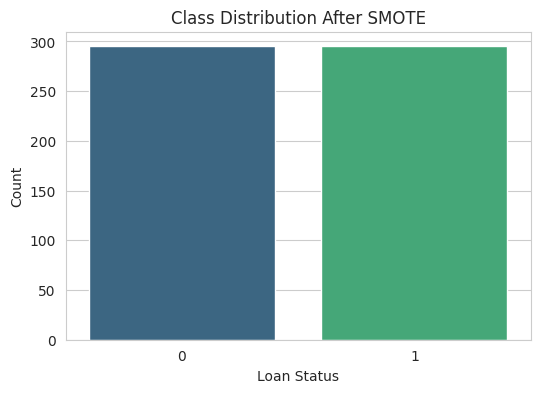

Class value counts after SMOTE:
 Loan_Status
1    295
0    295
Name: count, dtype: int64
SMOTE Model Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.66      0.64        58
           1       0.84      0.82      0.83       127

    accuracy                           0.77       185
   macro avg       0.73      0.74      0.73       185
weighted avg       0.77      0.77      0.77       185

SMOTE Model F1 Score: 0.8287

Comparison of Models:
Baseline Model F1 Score: 0.8712
SMOTE Model F1 Score   : 0.8287


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For splitting data and modeling
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report

# For handling categorical data
from sklearn.preprocessing import LabelEncoder

# For SMOTE
from imblearn.over_sampling import SMOTE

# Load the dataset
df = pd.read_csv("loan_dataset_imputed.csv")

# Drop Loan_ID if it exists (since it's just an identifier)
if 'Loan_ID' in df.columns:
    df.drop(columns=['Loan_ID'], inplace=True)

# Convert categorical target variable if needed
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})  # Convert 'Y' to 1 and 'N' to 0

# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

# Encode categorical variables
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Save encoders in case we need to inverse transform later

# Define features and target
X = df.drop(columns=['Loan_Status'])  # Features
y = df['Loan_Status']  # Target variable

# Ensure the target variable is an integer
y = y.astype(int)

# 1. Analyze the Class Imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='viridis')
plt.title('Class Distribution Before SMOTE')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

# Print value counts for the target class
print("Class value counts before SMOTE:\n", y.value_counts())

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Train Baseline Model Without SMOTE
clf_baseline = RandomForestClassifier(random_state=42)
clf_baseline.fit(X_train, y_train)

# Predict on the test set
y_pred_baseline = clf_baseline.predict(X_test)

# Evaluate the model using F1 Score
f1_baseline = f1_score(y_test, y_pred_baseline)
print("Baseline Model Classification Report:")
print(classification_report(y_test, y_pred_baseline))
print(f"Baseline Model F1 Score: {f1_baseline:.4f}\n")

# 4. Apply SMOTE to Handle Class Imbalance
smote = SMOTE(sampling_strategy='auto', random_state=42)  # Balances classes equally
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check the new class distribution after SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_smote, palette='viridis')
plt.title('Class Distribution After SMOTE')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()
print("Class value counts after SMOTE:\n", pd.Series(y_train_smote).value_counts())

# 5. Train the Model After Applying SMOTE
clf_smote = RandomForestClassifier(random_state=42)
clf_smote.fit(X_train_smote, y_train_smote)

# Predict on the test set
y_pred_smote = clf_smote.predict(X_test)

# Evaluate the SMOTE model using F1 Score
f1_smote = f1_score(y_test, y_pred_smote)
print("SMOTE Model Classification Report:")
print(classification_report(y_test, y_pred_smote))
print(f"SMOTE Model F1 Score: {f1_smote:.4f}\n")

# 6. Compare Model Performance Before and After SMOTE
print("Comparison of Models:")
print(f"Baseline Model F1 Score: {f1_baseline:.4f}")
print(f"SMOTE Model F1 Score   : {f1_smote:.4f}")


# **EXP 9 : Inferential statistics -Hypothesis Testing, Z test, T-Test , Anova**

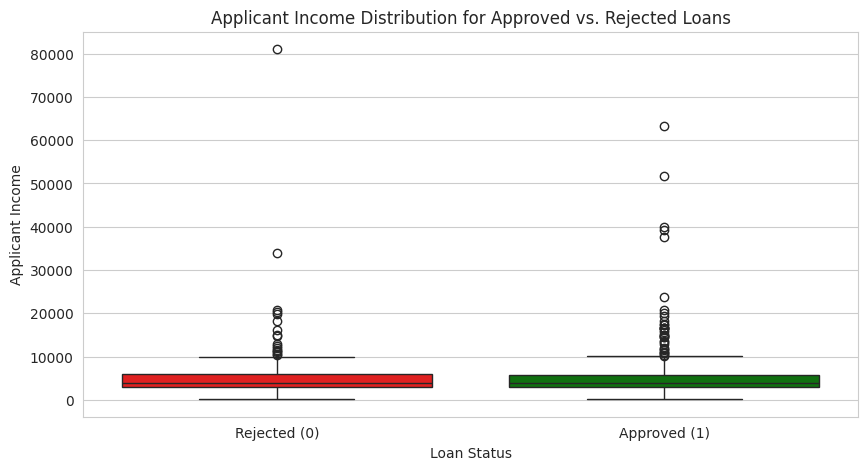

Z-Test: Z-Statistic = -0.1094, P-value = 0.9129
Fail to Reject Null Hypothesis: No significant difference in income between groups.



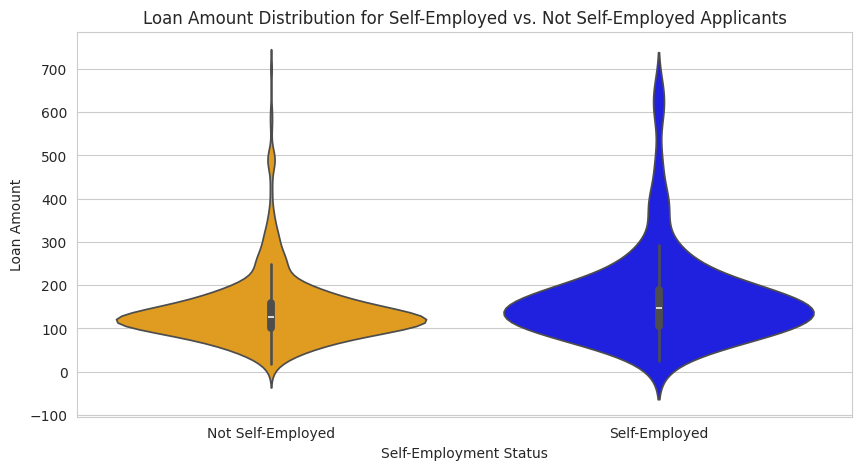

T-Test: T-Statistic = 2.2895, P-value = 0.0243
Reject Null Hypothesis: Significant difference in loan amounts between self-employed and non-self-employed applicants.



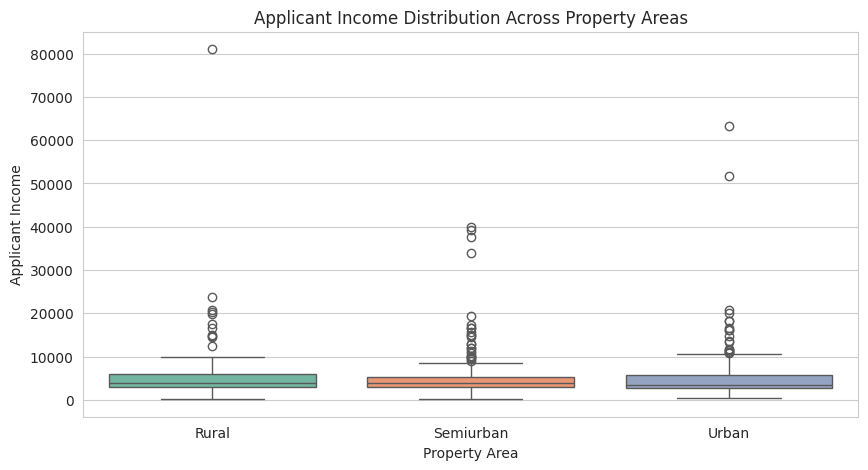

ANOVA Test: F-Statistic = 0.0928, P-value = 0.9114
Fail to Reject Null Hypothesis: No significant difference in applicant income across areas.



In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("loan_dataset_imputed.csv")

# Drop Loan_ID if present
if 'Loan_ID' in df.columns:
    df.drop(columns=['Loan_ID'], inplace=True)

# Convert categorical target variable if needed
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})  # Convert 'Y' to 1 and 'N' to 0

# Identify numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Set Seaborn style
sns.set_style("whitegrid")


# 1. Z-Test (Comparing Approved vs. Rejected Loans on ApplicantIncome)

income_approved = df[df['Loan_Status'] == 1]['ApplicantIncome']
income_rejected = df[df['Loan_Status'] == 0]['ApplicantIncome']

# Perform Z-Test (using t-test as an approximation)
z_stat, z_p_value = stats.ttest_ind(income_approved, income_rejected, equal_var=False)

# Boxplot Visualization
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Loan_Status'], y=df['ApplicantIncome'], palette=['red', 'green'])
plt.xticks([0, 1], ['Rejected (0)', 'Approved (1)'])
plt.title("Applicant Income Distribution for Approved vs. Rejected Loans")
plt.xlabel("Loan Status")
plt.ylabel("Applicant Income")
plt.show()

# Print results
print(f"Z-Test: Z-Statistic = {z_stat:.4f}, P-value = {z_p_value:.4f}")
if z_p_value < 0.05:
    print("Reject Null Hypothesis: Significant difference in income between approved and rejected loans.\n")
else:
    print("Fail to Reject Null Hypothesis: No significant difference in income between groups.\n")


# 2. T-Test (Comparing Loan Amount for Self-Employed vs. Not Self-Employed)

if 'Self_Employed' in df.columns and 'LoanAmount' in df.columns:
    df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
    loan_self_emp = df[df['Self_Employed'] == 1]['LoanAmount']
    loan_non_self_emp = df[df['Self_Employed'] == 0]['LoanAmount']

    # Perform T-Test
    t_stat, t_p_value = stats.ttest_ind(loan_self_emp.dropna(), loan_non_self_emp.dropna(), equal_var=False)

    # Violin Plot Visualization
    plt.figure(figsize=(10, 5))
    sns.violinplot(x=df['Self_Employed'], y=df['LoanAmount'], palette=['orange', 'blue'])
    plt.xticks([0, 1], ['Not Self-Employed', 'Self-Employed'])
    plt.title("Loan Amount Distribution for Self-Employed vs. Not Self-Employed Applicants")
    plt.xlabel("Self-Employment Status")
    plt.ylabel("Loan Amount")
    plt.show()

    # Print results
    print(f"T-Test: T-Statistic = {t_stat:.4f}, P-value = {t_p_value:.4f}")
    if t_p_value < 0.05:
        print("Reject Null Hypothesis: Significant difference in loan amounts between self-employed and non-self-employed applicants.\n")
    else:
        print("Fail to Reject Null Hypothesis: No significant difference in loan amounts between groups.\n")


# 3. ANOVA (Comparing Applicant Income Across Property Areas)

if 'Property_Area' in df.columns:
    df['Property_Area'] = df['Property_Area'].astype('category')

    # Extract applicant income for each property area
    groups = [df[df['Property_Area'] == area]['ApplicantIncome'].dropna() for area in df['Property_Area'].unique()]

    # Perform ANOVA
    f_stat, f_p_value = stats.f_oneway(*groups)

    # Boxplot for visualization
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df['Property_Area'], y=df['ApplicantIncome'], palette="Set2")
    plt.title("Applicant Income Distribution Across Property Areas")
    plt.xlabel("Property Area")
    plt.ylabel("Applicant Income")
    plt.show()

    # Print results
    print(f"ANOVA Test: F-Statistic = {f_stat:.4f}, P-value = {f_p_value:.4f}")
    if f_p_value < 0.05:
        print("Reject Null Hypothesis: Significant difference in applicant income across different property areas.\n")
    else:
        print("Fail to Reject Null Hypothesis: No significant difference in applicant income across areas.\n")
